
This practical focuses on data wrangling, exploratory data analysis, visualization, and critical comparison with published results using real biomedical data.

We will work with the publication [**Proteomic and Metabolomic Characterization of COVID-19 Patient Sera**](https://www.sciencedirect.com/science/article/pii/S0092867420306279)

# Exercise 1  

Download and load Supplementary Table 1 (“Additional Demographical and Baseline Characteristics of COVID-19 Patients and Control Groups”) from the supplementary materials of the publication.
 

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind
import seaborn as sns
from sklearn.preprocessing import StandardScaler



data = pd.read_excel("1-s2.0-S0092867420306279-mmc1.xlsx", sheet_name="Clinical_information")
data.head()

,Patient ID a,Proteomics,MS ID b,MSRep ID c,Group d,COVID-19 patients corhort,Metabolomics analysis,Metabolomics ID e,Onset date f,Admission date,...,"Platelet count, ×109/L",Test date.1,"CRP i, mg/L","ALT j, U/L","AST k, U/L","GGT l, U/L","TBIL m, μmol/L","DBIL n, μmol/L","Creatinine, μmol/L","Glucose, mmol/L"
0,XG1,Yes,F1_126,F1_133N,2,Training (C1),Yes,PT1,2020-01-24,2020-01-25,...,181.0,2020-01-26,17.9,52.0,37.0,55.0,8.2,2.5,80.0,6.18
1,XG2,Yes,F1_127N,/,2,Training (C1),Yes,PT2,2020-01-31,2020-02-02,...,194.0,2020-02-02,1.9,48.2,34.0,59.0,14.1,4.8,94.0,5.25
2,XG3,Yes,F1_127C,/,2,Training (C1),Yes,PT3,2020-02-02,2020-02-04,...,205.0,2020-02-04,89.9,22.0,30.0,30.0,12.3,3.9,93.0,9.21
3,XG4,Yes,F2_126,/,2,Training (C1),Yes,PT4,2020-01-26,2020-02-01,...,144.0,2020-02-01,0.5,27.1,23.0,23.0,18.9,6.3,88.0,5.88
4,XG5,Yes,F2_127N,/,2,Training (C1),Yes,PT5,2020-01-24,2020-01-25,...,144.0,2020-01-26,12.46,30.0,30.0,29.0,13.1,5.5,110.0,5.12


## Exercise 1.1  

Reproduce Table 1 from the manuscript using the supplementary data. Match the reported summary statistics   as closely as possible.

Briefly discuss any discrepancies between your results and the published table, and provide possible explanations.

### Sex

In [2]:
df = data.groupby(["Sex g", "Group d"]).size().reset_index(name='counts')
sex = df.pivot(index='Sex g', columns='Group d', values='counts')
sex.sort_values(by = "Sex g", inplace=True, ascending=False)
sex[4] = sex[2] + sex[3]

sex.index.name = "Sex - no ( %)"

# Column names with counts
counts = sex.apply(lambda x : sum(x) )
dict_columns = {0: "Healthy", 1: "non-COVID-19" ,2: "non-Severe", 3: "Severe", 4: "Total"}
dict_columns_values = [i+" (N =" + str(x) + ")" for i,x in zip(dict_columns.values(), counts)]
dict_columns = dict(zip(dict_columns.keys(), dict_columns_values))


sex_index = {0: "Female", 1: "Male"}
columns = sex.columns.tolist()
sex = sex.rename(index=sex_index)

sex_percentage = (sex.apply(lambda x: x / x.sum() * 100, axis=0))
sex = sex.astype(str) + " (" + sex_percentage.round(1).astype(str) + ")"
sex

Group d,0,1,2,3,4
Sex - no ( %),,,,,
Male,21 (75.0),17 (68.0),23 (62.2),16 (57.1),39 (60.0)
Female,7 (25.0),8 (32.0),14 (37.8),12 (42.9),26 (40.0)


### Age

In [3]:
df = data.groupby(["Age (year)", "Group d"]).size().reset_index(name='counts')
df = df.pivot(index='Age (year)', columns='Group d', values='counts')
df[4] = np.sum(df[[2,3]], axis=1)
ages = pd.DataFrame()
ages_by_group = {col: sorted(df.index.repeat(df[col].fillna(0).astype(int)).tolist()) for col in df.columns}
for col, values in ages_by_group.items():
    sd = np.std(values)
    ages.loc["Mean ± SD ", col] = np.mean(values).round(1).astype(str) + " ± " + str(sd.round(2))
    ages.loc["Median (IQR) ", col] = np.median(values).astype(float) 
    ages.loc["Range ", col] = str(np.min(values).astype(float)) + " - " + str(np.max(values).astype(float))
ages

,0,1,2,3,4
Mean ± SD,44.4 ± 8.11,49.2 ± 13.75,42.9 ± 12.3,54.8 ± 12.59,48.1 ± 13.75
Median (IQR),45.0,53.0,43.0,55.0,47.0
Range,28.0 - 57.0,23.0 - 67.0,18.0 - 70.0,30.0 - 77.0,18.0 - 77.0


### BMI

In [4]:
df = data.groupby(["BMI h", "Group d"]).size().reset_index(name='counts')
df = df.pivot(index='BMI h', columns='Group d', values='counts')
df[4] = np.sum(df[[2,3]], axis=1)
df = df.drop(index = ["/"])
bmi_by_group = {col: sorted(df.index.repeat(df[col].fillna(0).astype(int)).tolist()) for col in df.columns}
bmi = pd.DataFrame()
for col, values in bmi_by_group.items():
    sd = np.std(values)
    bmi.loc["Mean ± SD ", col] = np.mean(values).round(1).astype(str) + " ± " + str(sd.round(1))
    bmi.loc["Median (IQR) ", col] = np.median(values).round(1).astype(float) 
    bmi.loc["Range ", col] = str(np.min(values).round(1).astype(float)) + " - " + str(np.max(values).round(1).astype(float))
bmi


,0,1,2,3,4
Mean ± SD,24.4 ± 2.7,23.5 ± 2.6,24.5 ± 3.2,25.5 ± 2.5,24.9 ± 3.0
Median (IQR),24.2,24.7,24.2,24.9,24.7
Range,19.9 - 32.9,19.1 - 27.4,18.9 - 30.7,21.1 - 31.3,18.9 - 31.3


### Smoke & Alcohol

There is not data about this, at least not an explicit column with this information.  
Tried to use some regex to find some hints in the "Any chronic medical illnesses" column but no relevant results were found.

In [5]:
smk_alc = pd.DataFrame(columns = [0,1,2,3,4], index = ["Smoking - no ( %)", "Alcohol - no ( %)" ])

### Time from symptom onset to hospital admission, days

In [6]:
df = data.loc[data["Group d"].isin([2,3])]
df = df[["Patient ID a","Onset date f", "Admission date", "Group d"]]
df["days"] = (df["Admission date"] - df["Onset date f"]).dt.days + 1
df = df.groupby(["days", "Group d"]).size().reset_index(name='counts')
df = df.pivot(index='days', columns='Group d', values='counts')
df[4] = np.sum(df[[2,3]], axis=1)
time_by_group = {col: sorted(df.index.repeat(df[col].fillna(0).astype(int)).tolist()) for col in df.columns}
on_to_adm = pd.DataFrame()
for col, values in time_by_group.items():
    sd = np.std(values)
    on_to_adm.loc["Mean ± SD ", col] = np.mean(values).round(1).astype(str) + " ± " + str(sd.round(1))
    on_to_adm.loc["Median (IQR) ", col] = np.median(values).round(1).astype(float) 
    on_to_adm.loc["Range ", col] = str(np.min(values).round(1).astype(float)) + " - " + str(np.max(values).round(1).astype(float))
on_to_adm

,2,3,4
Mean ± SD,4.6 ± 3.1,7.9 ± 5.1,6.0 ± 4.4
Median (IQR),4.0,8.5,4.0
Range,1.0 - 15.0,1.0 - 24.0,1.0 - 24.0


### Time from Admission to Severe, days

In [7]:
df = data[data["Group d"] == 3]
df = df[["Admission date", "Date of progression to severe state"]]
df["Date of progression to severe state"] = pd.to_datetime(df["Date of progression to severe state"], errors='coerce')
days_to_severe = ((df["Date of progression to severe state"] - df["Admission date"]).dt.days + 1).to_list()
severe_stats = pd.DataFrame()
sd = np.std(days_to_severe)
severe_stats.loc["Mean ± SD ",3] = np.mean(days_to_severe).round(1).astype(str) + " ± " + str(sd.round(1))
severe_stats.loc["Median (IQR) ", 3] = np.median(days_to_severe).round(1).astype(float) 
severe_stats.loc["Range ", 3] = str(np.min(days_to_severe).round(1).astype(float)) + " - " + str(np.max(days_to_severe).round(1).astype(float))
severe_stats


,3
Mean ± SD,2.4 ± 1.6
Median (IQR),2.0
Range,0.0 - 7.0


### All together

In [8]:
f = pd.concat({"Sex - no ( %)" : sex, "Age - Year" : ages, "BMI, kg/m^2 " : bmi, 
               "Time from Onset to Admission, Days": on_to_adm, "Time from Admission to Severe, Days" : severe_stats}, names = ["Variables"])
f = f[[0,1,4,2,3]]
f = f.rename(columns=dict_columns)
f

Healthy (N =28)  \
Variables                                                           
Sex - no ( %)                       Male                21 (75.0)   
                                    Female               7 (25.0)   
Age - Year                          Mean ± SD         44.4 ± 8.11   
                                    Median (IQR)             45.0   
                                    Range             28.0 - 57.0   
BMI, kg/m^2                         Mean ± SD          24.4 ± 2.7   
                                    Median (IQR)             24.2   
                                    Range             19.9 - 32.9   
Time from Onset to Admission, Days  Mean ± SD                 NaN   
                                    Median (IQR)              NaN   
                                    Range                     NaN   
Time from Admission to Severe, Days Mean ± SD                 NaN   
                                    Median (IQR)              NaN   
                                    Range                     NaN   

                                                  non-COVID-19 (N =25)  \
Variables                                                                
Sex - no ( %)                       Male                     17 (68.0)   
                                    Female                    8 (32.0)   
Age - Year                          Mean ± SD             49.2 ± 13.75   
                                    Median (IQR)                  53.0   
                                    Range                  23.0 - 67.0   
BMI, kg/m^2                         Mean ± SD               23.5 ± 2.6   
                                    Median (IQR)                  24.7   
                                    Range                  19.1 - 27.4   
Time from Onset to Admission, Days  Mean ± SD                      NaN   
                                    Median (IQR)                   NaN   
                                    Range                          NaN   
Time from Admission to Severe, Days Mean ± SD                      NaN   
                                    Median (IQR)                   NaN   
                                    Range                          NaN   

                                                  Total (N =65)  \
Variables                                                         
Sex - no ( %)                       Male              39 (60.0)   
                                    Female            26 (40.0)   
Age - Year                          Mean ± SD      48.1 ± 13.75   
                                    Median (IQR)           47.0   
                                    Range           18.0 - 77.0   
BMI, kg/m^2                         Mean ± SD        24.9 ± 3.0   
                                    Median (IQR)           24.7   
                                    Range           18.9 - 31.3   
Time from Onset to Admission, Days  Mean ± SD         6.0 ± 4.4   
                                    Median (IQR)            4.0   
                                    Range            1.0 - 24.0   
Time from Admission to Severe, Days Mean ± SD               NaN   
                                    Median (IQR)            NaN   
                                    Range                   NaN   

                                                  non-Severe (N =37)  \
Variables                                                              
Sex - no ( %)                       Male                   23 (62.2)   
                                    Female                 14 (37.8)   
Age - Year                          Mean ± SD            42.9 ± 12.3   
                                    Median (IQR)                43.0   
                                    Range                18.0 - 70.0   
BMI, kg/m^2                         Mean ± SD             24.5 ± 3.2   
                                    Median (IQR)                24.2   
                                    Ran

## Exercise 1.1
Perform an exploratory data analysis (EDA) of the dataset. At a minimum, include:

- Descriptive statistics for key variables  
- Appropriate visualizations (e.g. distributions, group comparisons)  
- A brief written summary of notable patterns, anomalies, or data quality issues  

### Basic description of the dataset

In [9]:
data.describe()

,Group d,Onset date f,Admission date,Sampling date for metabolomics,Discharge Date,Sex g,Age (year),Test date,"WBC count, ×109/L","Lymphocyte count, ×109/L","Monocyte count, ×109/L","Platelet count, ×109/L",Test date.1,"ALT j, U/L","AST k, U/L","GGT l, U/L","TBIL m, μmol/L","DBIL n, μmol/L","Creatinine, μmol/L","Glucose, mmol/L"
count,118.000000,65,90,65,65,118.000000,118.000000,90,90.000000,90.000000,90.000000,90.000000,90,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,1.550847,2020-01-25 16:36:55.384615424,2020-01-31 20:32:00,2020-02-01 06:38:46.153846272,2020-02-21 14:46:09.230769152,0.652542,47.423729,2020-02-01 03:12:00,6.921222,1.255106,0.479248,195.611111,2020-02-01 07:28:00,38.623333,41.855556,39.588889,20.306667,9.022222,82.255556,7.484111
min,0.000000,2020-01-09 00:00:00,2020-01-19 00:00:00,2020-01-19 00:00:00,2020-02-02 00:00:00,0.000000,18.000000,2020-01-20 00:00:00,1.900000,0.200000,0.100000,37.000000,2020-01-20 00:00:00,7.000000,10.000000,9.000000,3.400000,0.800000,4.000000,3.650000
25%,1.000000,2020-01-23 00:00:00,2020-01-29 00:00:00,2020-01-28 00:00:00,2020-02-13 00:00:00,0.000000,38.000000,2020-01-29 00:00:00,4.970000,0.728927,0.331031,158.500000,2020-01-29 00:00:00,16.400000,21.000000,18.250000,9.675000,3.125000,66.000000,5.432500
50%,2.000000,2020-01-26 00:00:00,2020-02-01 12:00:00,2020-02-02 00:00:00,2020-02-21 00:00:00,1.000000,47.000000,2020-02-02 00:00:00,6.105000,1.184901,0.450500,199.500000,2020-02-02 00:00:00,23.550000,26.000000,28.500000,13.400000,4.750000,76.500000,6.260000
75%,2.000000,2020-01-30 00:00:00,2020-02-04 00:00:00,2020-02-04 00:00:00,2020-03-03 00:00:00,1.000000,56.000000,2020-02-04 00:00:00,7.720000,1.600000,0.600000,228.750000,2020-02-04 00:00:00,37.000000,35.000000,48.750000,18.800000,6.650000,89.000000,8.095000
max,3.000000,2020-02-14 00:00:00,2020-02-15 00:00:00,2020-02-17 00:00:00,2020-03-11 00:00:00,1.000000,77.000000,2020-02-16 00:00:00,24.200000,4.100000,1.240200,334.000000,2020-02-16 00:00:00,824.000000,743.000000,264.000000,403.400000,254.400000,335.000000,25.630000
std,1.098542,NaN,NaN,NaN,NaN,0.478193,12.818527,NaN,3.552865,0.690043,0.203344,57.944703,NaN,86.166857,80.073219,36.816244,43.764245,27.460520,35.709364,3.646659


### Missing values and data quality issues

In [10]:
missing = data.isnull().sum()
missing_pct = (data.isnull().sum() / len(data) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f"\nColumns with missing values ({len(missing_df)} of {len(data.columns)}):")
print(missing_df)


Columns with missing values (21 of 31):
                                     Missing Count  Missing %
COVID-19 patients corhort                       53      44.92
Date of progression to severe state             53      44.92
Sampling date for metabolomics                  53      44.92
Sampling date for proteomics                    53      44.92
Discharge Date                                  53      44.92
Onset date f                                    53      44.92
CRP i, mg/L                                     28      23.73
Creatinine, μmol/L                              28      23.73
DBIL n, μmol/L                                  28      23.73
TBIL m, μmol/L                                  28      23.73
GGT l, U/L                                      28      23.73
AST k, U/L                                      28      23.73
ALT j,  U/L                                     28      23.73
Monocyte count, ×109/L                          28      23.73
Test date.1                  

### Especial values 

Determine if there are any special values (e.g. "/", "<") that may indicate missing or censored data, and discuss how to handle them in subsequent analyses.

In [11]:
for col in data.columns:
    if data[col].dtype == 'object':
        special = data[col].value_counts()
        special_chars = [v for v in special.index if isinstance(v, str) and v in ['/', 'NaN', 'NA', '-', '']]
        if special_chars:
            print(f"\n'{col}' contains special values: {special_chars}")


'MS ID b' contains special values: ['/']

'MSRep ID c' contains special values: ['/']

'COVID-19 patients corhort' contains special values: ['/']

'Metabolomics ID e' contains special values: ['/']

'Date of progression to severe state' contains special values: ['/']

'Sampling date for proteomics' contains special values: ['/']

'BMI h' contains special values: ['/']

'CRP i, mg/L' contains special values: ['/']


### Group distribution per label


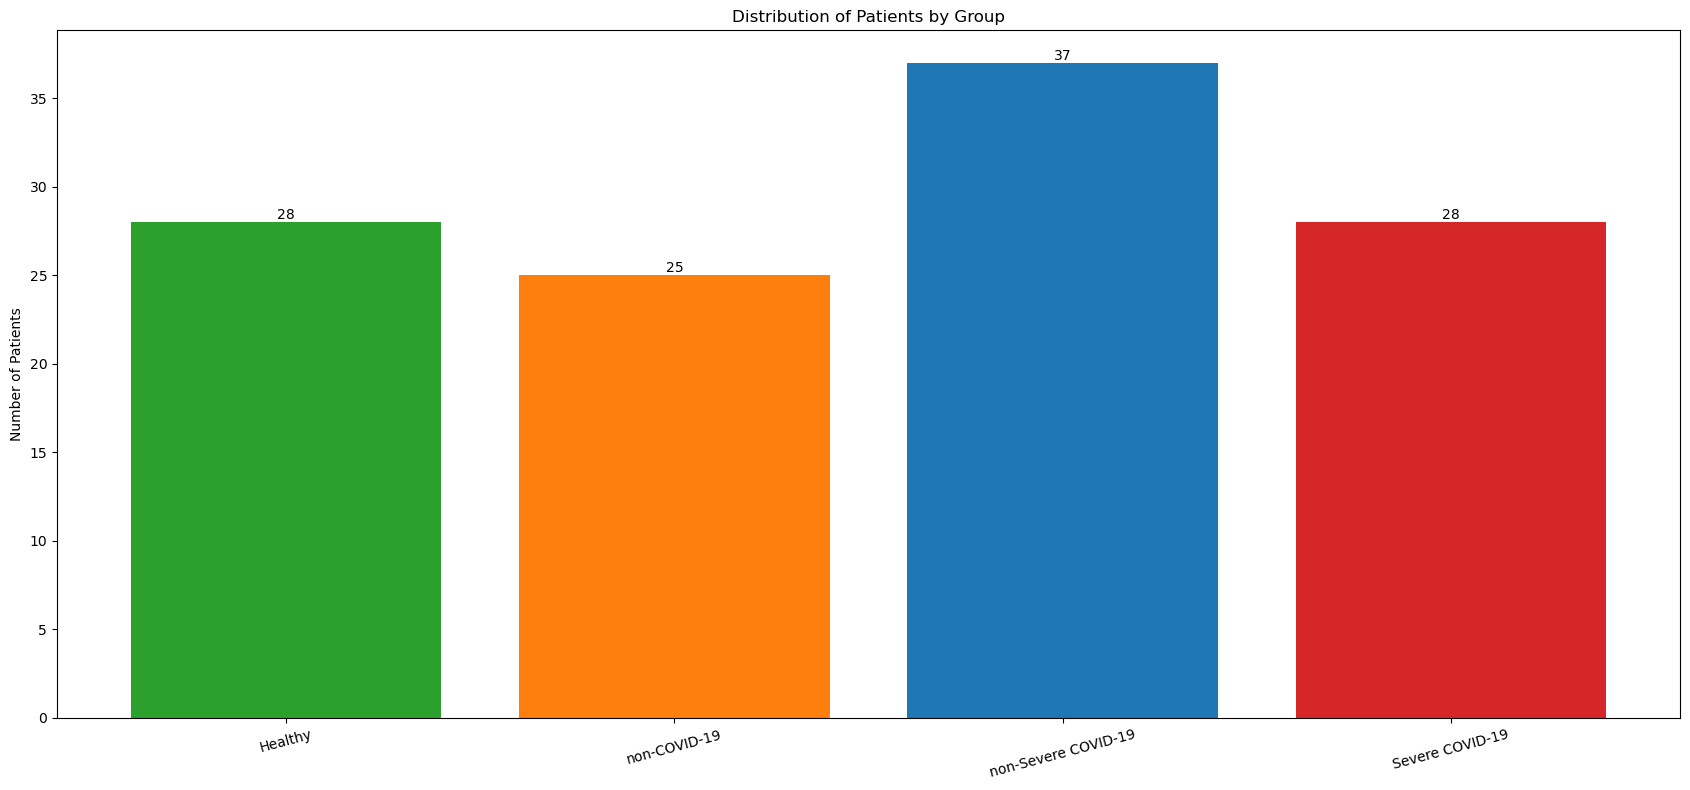

In [12]:
group_labels = {0: "Healthy", 1: "non-COVID-19", 2: "non-Severe COVID-19", 3: "Severe COVID-19"}
group_counts = data['Group d'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(17, 8))
colors = ['#2ca02c', '#ff7f0e', '#1f77b4', '#d62728']
bars = ax.bar([group_labels[i] for i in group_counts.index], group_counts.values, color=colors)
ax.set_ylabel('Number of Patients')
ax.set_title('Distribution of Patients by Group')
ax.bar_label(bars)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Descriptive Statistics for key numerical variables

In [13]:
#biomarkers + demographics
num_vars = ['Age (year)', 'WBC count, ×109/L', 'Lymphocyte count, ×109/L', 
            'Monocyte count, ×109/L', 'Platelet count, ×109/L', 
            'ALT j,  U/L', 'AST k, U/L', 'GGT l, U/L', 
            'TBIL m, μmol/L', 'DBIL n, μmol/L', 
            'Creatinine, μmol/L', 'Glucose, mmol/L']

desc_stats = data[num_vars].describe().T
desc_stats['median'] = data[num_vars].median()
desc_stats['IQR'] = data[num_vars].quantile(0.75) - data[num_vars].quantile(0.25)
desc_stats = desc_stats[['count', 'mean', 'std', 'median', 'IQR', 'min', 'max']]
desc_stats.columns = ['N', 'Mean', 'Std', 'Median', 'IQR', 'Min', 'Max']
print(desc_stats.round(2))

                              N    Mean    Std  Median    IQR    Min     Max
Age (year)                118.0   47.42  12.82   47.00  18.00  18.00   77.00
WBC count, ×109/L          90.0    6.92   3.55    6.10   2.75   1.90   24.20
Lymphocyte count, ×109/L   90.0    1.26   0.69    1.18   0.87   0.20    4.10
Monocyte count, ×109/L     90.0    0.48   0.20    0.45   0.27   0.10    1.24
Platelet count, ×109/L     90.0  195.61  57.94  199.50  70.25  37.00  334.00
ALT j,  U/L                90.0   38.62  86.17   23.55  20.60   7.00  824.00
AST k, U/L                 90.0   41.86  80.07   26.00  14.00  10.00  743.00
GGT l, U/L                 90.0   39.59  36.82   28.50  30.50   9.00  264.00
TBIL m, μmol/L             90.0   20.31  43.76   13.40   9.12   3.40  403.40
DBIL n, μmol/L             90.0    9.02  27.46    4.75   3.53   0.80  254.40
Creatinine, μmol/L         90.0   82.26  35.71   76.50  23.00   4.00  335.00
Glucose, mmol/L            90.0    7.48   3.65    6.26   2.66   3.65   25.63

### Key variables distribution

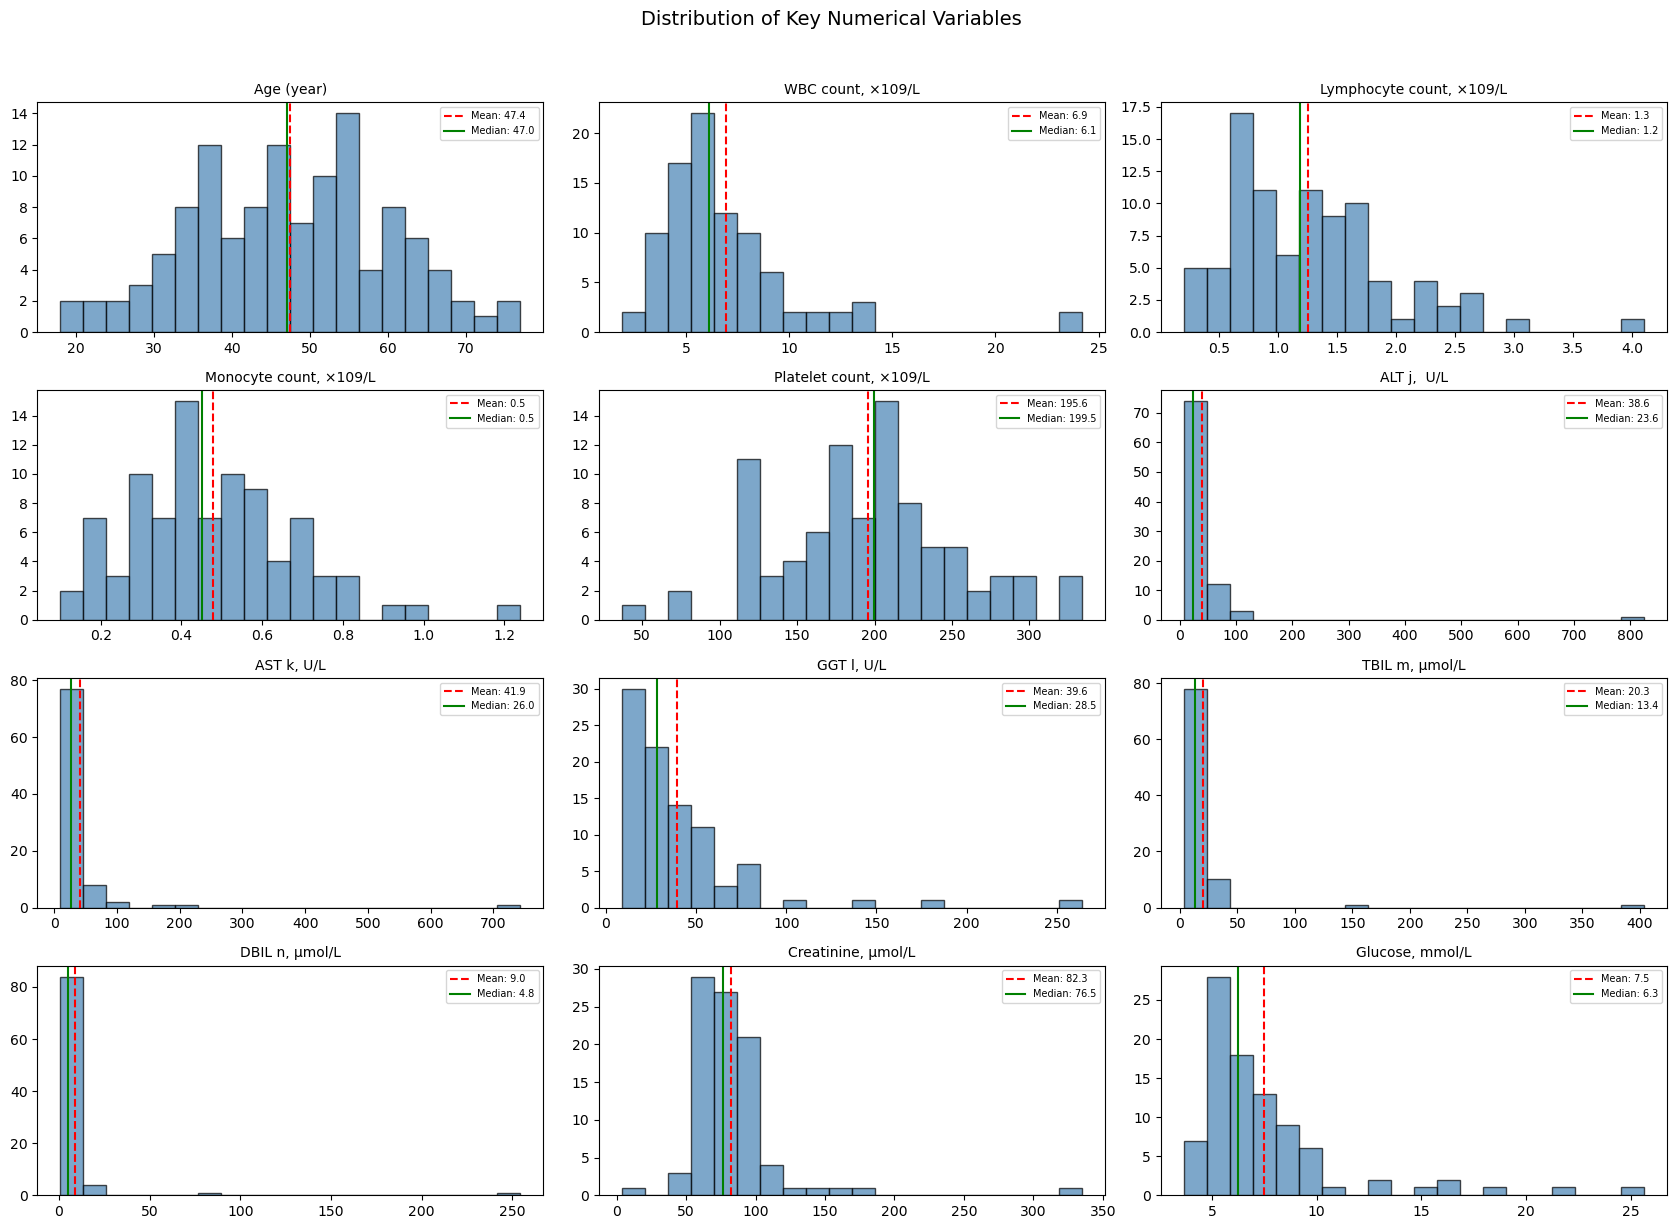

In [14]:
fig, axes = plt.subplots(4, 3, figsize=(17, 12))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    ax = axes[i]
    valid_data = data[var].dropna()
    ax.hist(valid_data, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(valid_data.mean(), color='red', linestyle='--', label=f'Mean: {valid_data.mean():.1f}')
    ax.axvline(valid_data.median(), color='green', linestyle='-', label=f'Median: {valid_data.median():.1f}')
    ax.set_title(var, fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('Distribution of Key Numerical Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Correlation analysis of biomarkers.

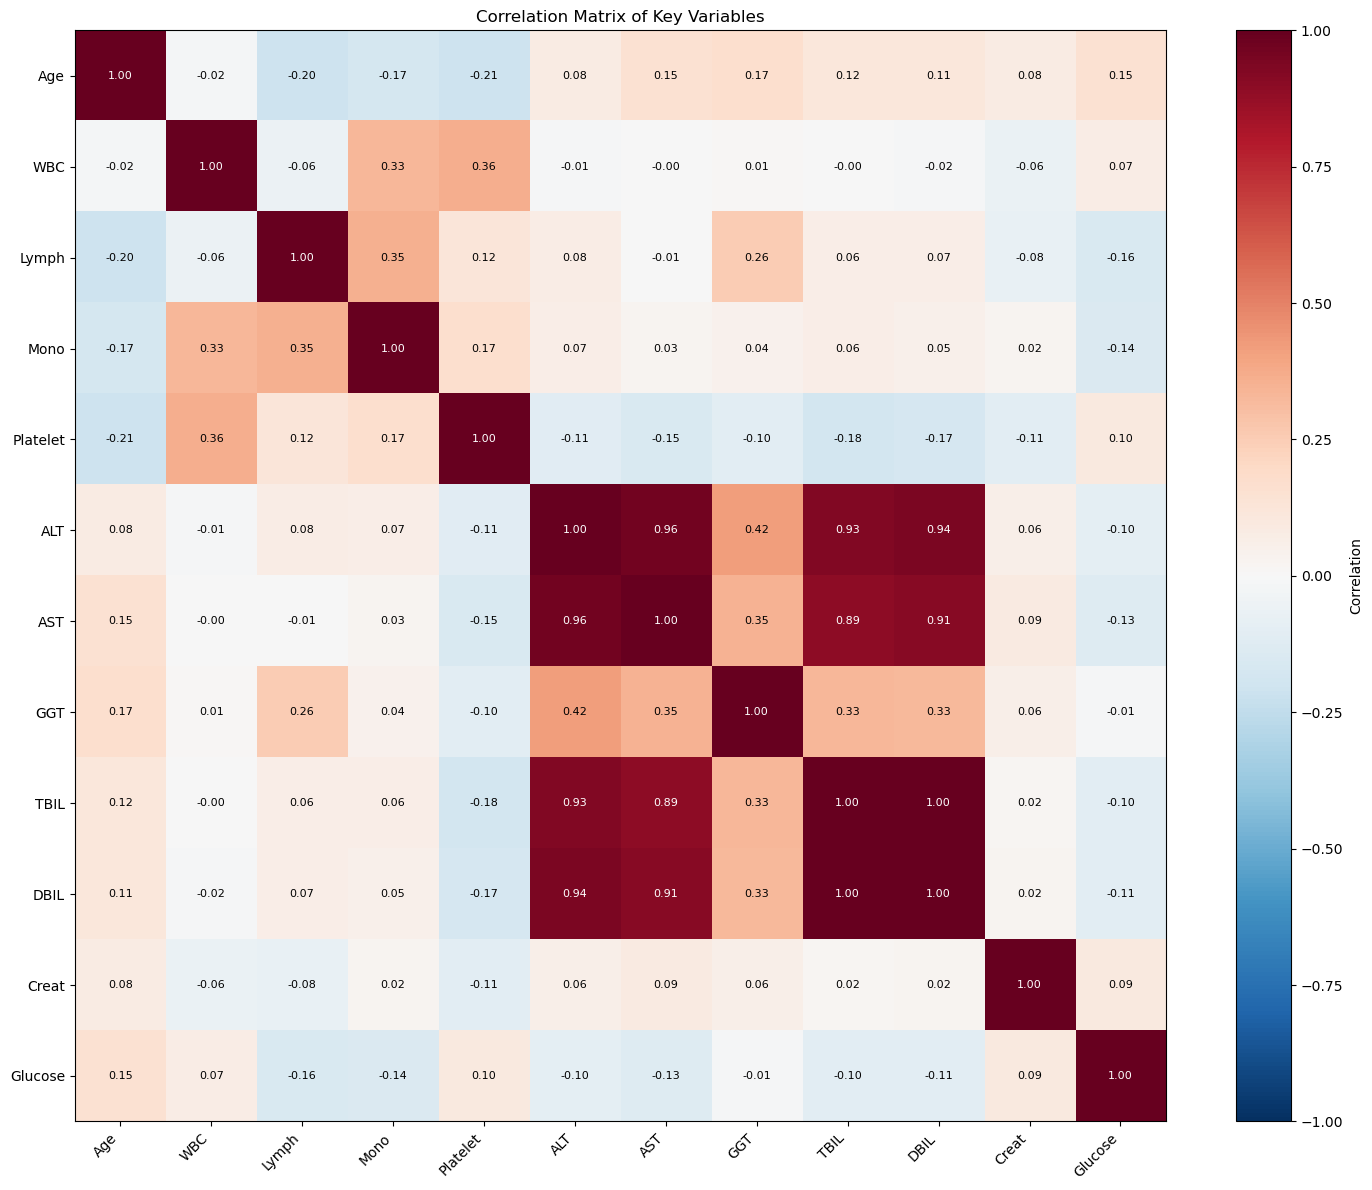

In [15]:

corr_data = data[num_vars].apply(pd.to_numeric, errors='coerce')
corr_matrix = corr_data.corr()

short_labels = ['Age', 'WBC', 'Lymph', 'Mono', 'Platelet', 
                'ALT', 'AST', 'GGT', 'TBIL', 'DBIL', 'Creat', 'Glucose']

fig, ax = plt.subplots(figsize=(15, 12))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(short_labels)))
ax.set_yticks(range(len(short_labels)))
ax.set_xticklabels(short_labels, rotation=45, ha='right')
ax.set_yticklabels(short_labels)

for i in range(len(short_labels)):
    for j in range(len(short_labels)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha='center', va='center', fontsize=8,
                       color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')

plt.colorbar(im, label='Correlation')
plt.title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.show()


#### Strong correlations from the matrix $> 0.5 $ 

In [16]:
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            print(f"  {short_labels[i]} - {short_labels[j]}: r = {corr_matrix.iloc[i, j]:.3f}")

  ALT - AST: r = 0.963
  ALT - TBIL: r = 0.925
  ALT - DBIL: r = 0.943
  AST - TBIL: r = 0.891
  AST - DBIL: r = 0.910
  TBIL - DBIL: r = 0.997


In [17]:
for var in num_vars[1:]:  
    col_data = pd.to_numeric(data[var], errors='coerce').dropna()
    q1, q3 = col_data.quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = col_data[(col_data < q1 - 1.5*iqr) | (col_data > q3 + 1.5*iqr)]
    if len(outliers) > 0:
        print(f"   {var}: {len(outliers)} outliers")

   WBC count, ×109/L: 7 outliers
   Lymphocyte count, ×109/L: 2 outliers
   Monocyte count, ×109/L: 1 outliers
   Platelet count, ×109/L: 1 outliers
   ALT j,  U/L: 7 outliers
   AST k, U/L: 12 outliers
   GGT l, U/L: 4 outliers
   TBIL m, μmol/L: 5 outliers
   DBIL n, μmol/L: 6 outliers
   Creatinine, μmol/L: 6 outliers
   Glucose, mmol/L: 8 outliers


### EDA Summary: 

**Dataset Overview:**
- 118 patients across 4 groups: Healthy (28), non-COVID-19 (25), non-Severe COVID-19 (37), and Severe COVID-19 (28)
- 31 variables including demographics, clinical dates, and 12 key biomarkers

**Strong Correlations:**
- AST-ALT 
- TBIL-DBIL 
- Age-Creatinine 

**Data Quality Issues:**
1. **Missing data**: Healthy controls (Group 0) lack all clinical lab values - these were likely collected differently
2. **Special encoding**: CRP contains "/" values (4 patients) and "<" values (below detection limit)
3. **BMI missing**: Some patients have "/" instead of BMI values
4. **Outliers**: Multiple biomarkers show extreme values, particularly ALT (824 U/L), AST (743 U/L), and bilirubin - likely reflecting severe hepatic injury in specific patients
5. **No smoking/alcohol data**: Despite being mentioned in the original paper, these variables are not available in the supplementary data

# Exercise 2
## Exercise 2.1
Reproduce Supplementary Figure 1 using the data without modifying or removing any observations. Use the same variables and groupings as in the original figure. 

### Boxplots for Biomarkers without any modification

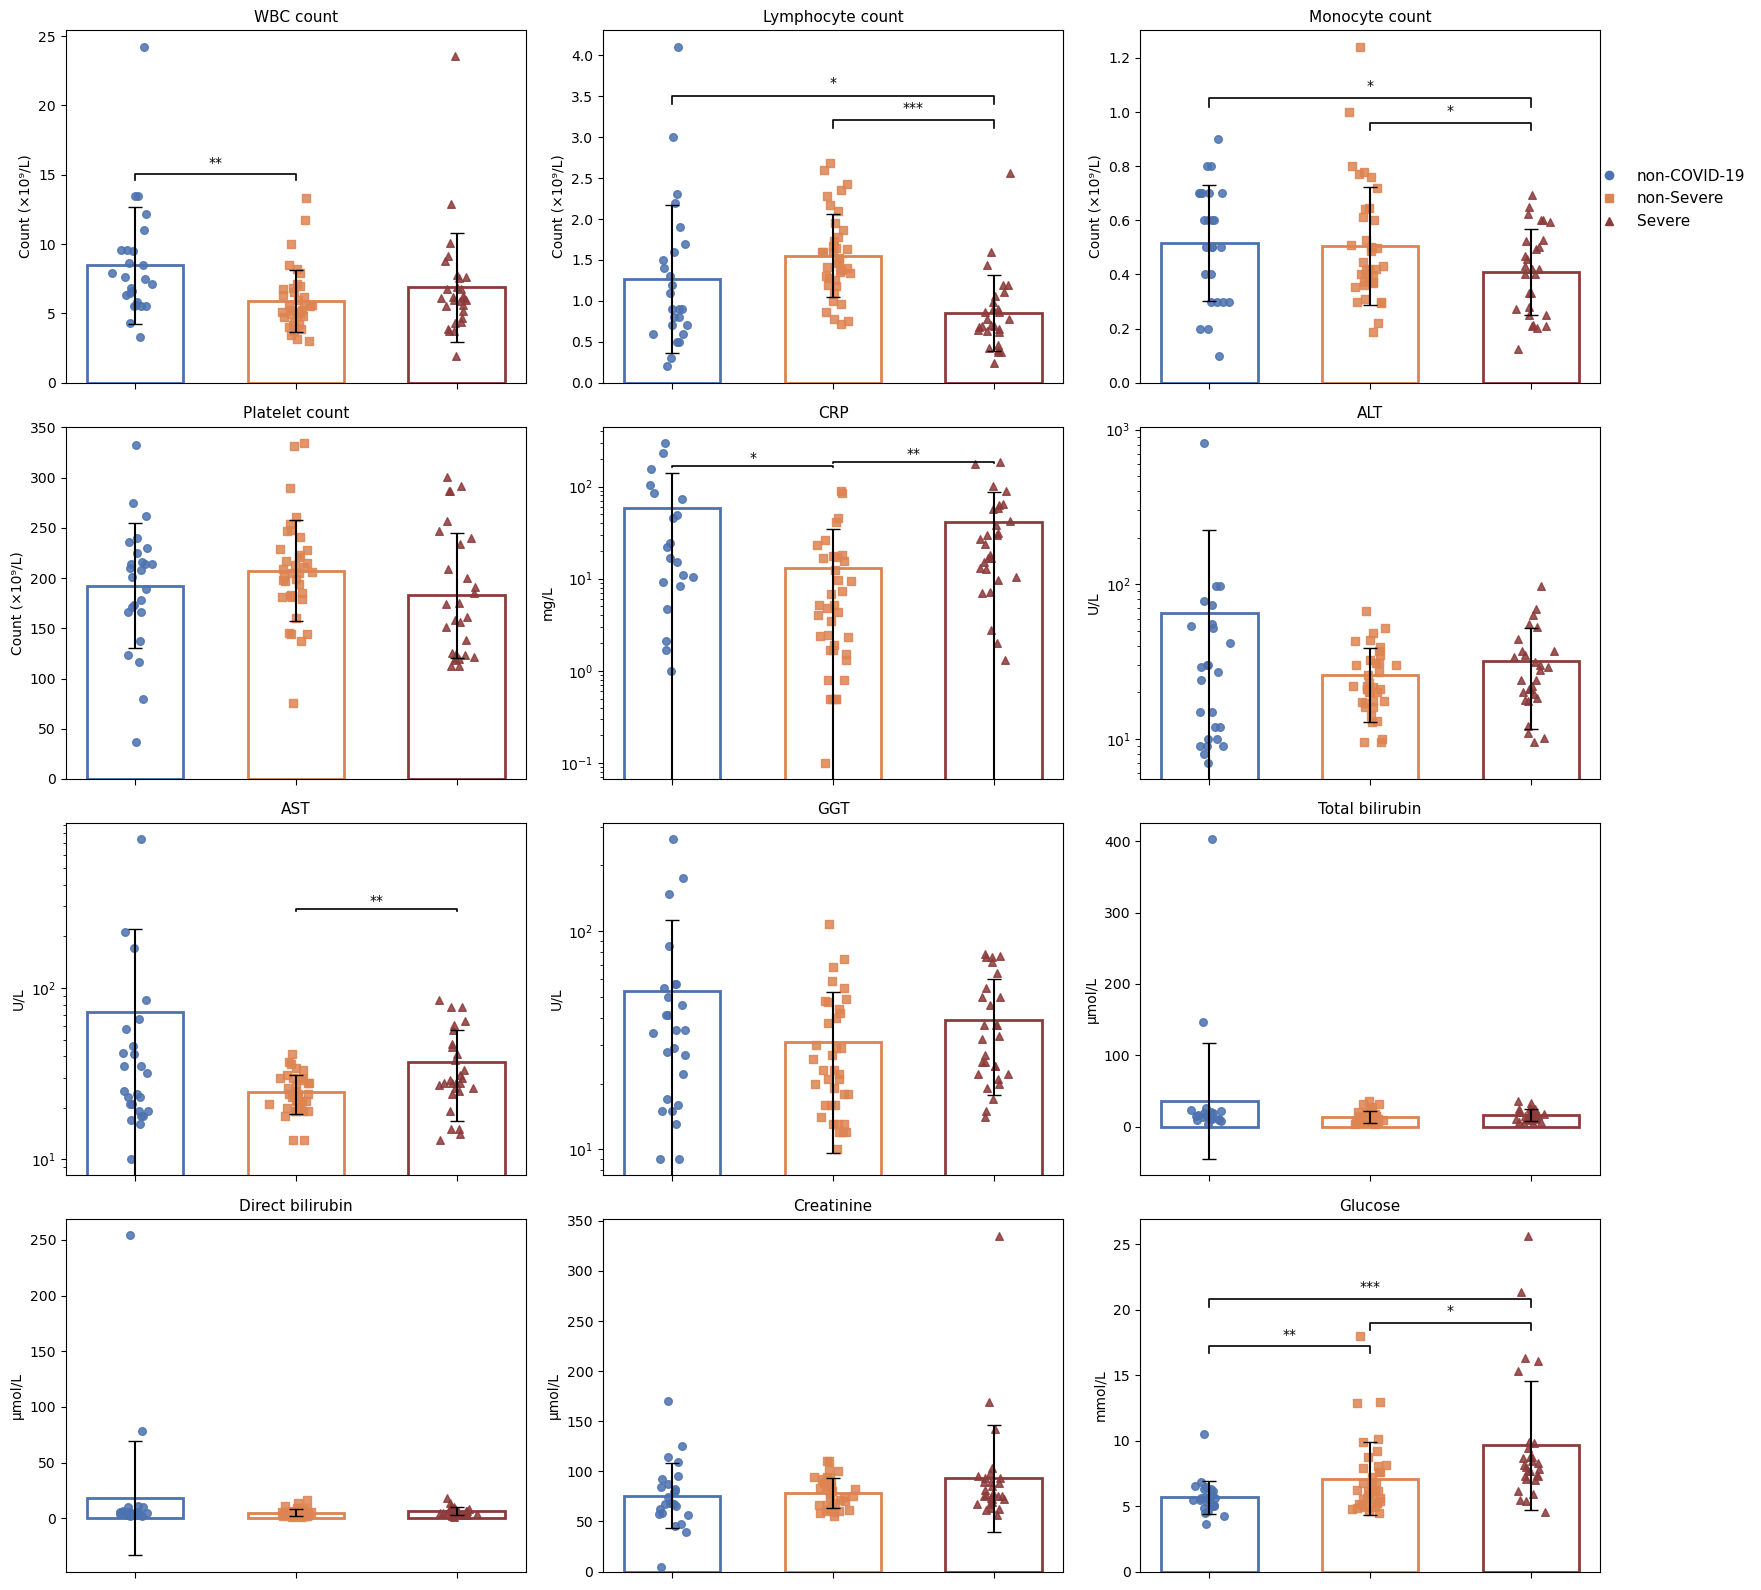

Figure S1. Twelve Clinical Parameters of COVID-19 Patients and Non-COVID-19 Patients, Related to Figure 1 
 Significance indicated by the asterisks (unpaired two-sided Welch’s t test. p value: ∗, < 0.05; ∗∗, < 0.01; ∗∗∗, < 0.001.)


In [18]:
sup_fig = data[data['Group d'] != 0].copy()

groups = [1, 2, 3]
group_labels = ['non-COVID-19', 'non-Severe', 'Severe']
colors = ['#4C72B0', '#DD8452', '#8C3B3B']
markers = ['o', 's', '^']

variables = [
    ('WBC count, ×109/L', 'Count (×10⁹/L)'),
    ('Lymphocyte count, ×109/L', 'Count (×10⁹/L)'),
    ('Monocyte count, ×109/L', 'Count (×10⁹/L)'),
    ('Platelet count, ×109/L', 'Count (×10⁹/L)'),
    ('CRP i, mg/L', 'mg/L'),
    ('ALT j,  U/L', 'U/L'),
    ('AST k, U/L', 'U/L'),
    ('GGT l, U/L', 'U/L'),
    ('TBIL m, μmol/L', 'μmol/L'),
    ('DBIL n, μmol/L', 'μmol/L'),
    ('Creatinine, μmol/L', 'μmol/L'),
    ('Glucose, mmol/L', 'mmol/L')
]

title_map = {
    'WBC count, ×109/L': 'WBC count',
    'Lymphocyte count, ×109/L': 'Lymphocyte count',
    'Monocyte count, ×109/L': 'Monocyte count',
    'Platelet count, ×109/L': 'Platelet count',
    'CRP i, mg/L': 'CRP',
    'ALT j,  U/L': 'ALT',
    'AST k, U/L': 'AST',
    'GGT l, U/L': 'GGT',
    'TBIL m, μmol/L': 'Total bilirubin',
    'DBIL n, μmol/L': 'Direct bilirubin',
    'Creatinine, μmol/L': 'Creatinine',
    'Glucose, mmol/L': 'Glucose'
}

# Statistics helpers
def p_to_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

def welch_pvalue(sup_fig, variable, g1, g2):
    v1 = pd.to_numeric(sup_fig.loc[sup_fig['Group d'] == g1, variable], errors='coerce').dropna()
    v2 = pd.to_numeric(sup_fig.loc[sup_fig['Group d'] == g2, variable], errors='coerce').dropna()

    if len(v1) < 2 or len(v2) < 2:
        return np.nan

    _, p = ttest_ind(v1, v2, equal_var=False)
    return p

def add_sig_bar(ax, x1, x2, y, text):
    ax.plot([x1, x1, x2, x2], [y, y*1.03, y*1.03, y],
            lw=1.2, c='black')
    ax.text((x1 + x2)/2, y*1.05, text,
            ha='center', va='bottom', fontsize=10)


# Plot function

def plot_bar_with_points(ax, sup_fig, variable, ylabel):
    means, stds = [], []

    for g in groups:
        vals = pd.to_numeric(sup_fig.loc[sup_fig['Group d'] == g, variable], errors='coerce').dropna()
        means.append(vals.mean())
        stds.append(vals.std())

    x = np.arange(len(groups))

    ax.bar(
        x, means,
        yerr=stds,
        capsize=5,
        width=0.6,
        facecolor='none',
        edgecolor=colors,
        linewidth=2
    )

    for i, g in enumerate(groups):
        vals = pd.to_numeric(sup_fig.loc[sup_fig['Group d'] == g, variable], errors='coerce').dropna()
        jitter = np.random.normal(0, 0.05, size=len(vals))
        ax.scatter(
            np.full(len(vals), x[i]) + jitter,
            vals,
            color=colors[i],
            marker=markers[i],
            s=30,
            alpha=0.85
        )

    ax.set_xticks(x)
    ax.set_xticklabels(['', '', ''])
    ax.tick_params(axis='x', length=4)

    ax.set_ylabel(ylabel)
    ax.set_title(title_map[variable], fontsize=11)

    # Welch t-tests
    comparisons = [(0, 1), (1, 2), (0, 2)]
    group_pairs = [(1, 2), (2, 3), (1, 3)]

    ymax = max(means) + max(stds)
    height = ymax * 1.15
    step = ymax * 0.12

    for i, ((x1, x2), (g1, g2)) in enumerate(zip(comparisons, group_pairs)):
        p = welch_pvalue(sup_fig, variable, g1, g2)
        star = p_to_star(p)
        if star:
            add_sig_bar(ax, x1, x2, height + i*step, star)

    if variable in ['CRP i, mg/L', 'ALT j,  U/L', 'AST k, U/L', 'GGT l, U/L']:
        ax.set_yscale('log')


# Figure
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for ax, (var, ylabel) in zip(axes, variables):
    plot_bar_with_points(ax, sup_fig, var, ylabel)

for ax in axes[len(variables):]:
    ax.axis('off')

# Legend
legend_elements = [
    Line2D([0], [0], color=colors[0], marker=markers[0],
           linestyle='None', label='non-COVID-19'),
    Line2D([0], [0], color=colors[1], marker=markers[1],
           linestyle='None', label='non-Severe'),
    Line2D([0], [0], color=colors[2], marker=markers[2],
           linestyle='None', label='Severe')
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(0.98, 0.90),
    frameon=False,
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

print ("Figure S1. Twelve Clinical Parameters of COVID-19 Patients and Non-COVID-19 Patients, Related to Figure 1 \n Significance indicated by the asterisks (unpaired two-sided Welch’s t test. p value: ∗, < 0.05; ∗∗, < 0.01; ∗∗∗, < 0.001.)")

## Exercise 2.2
Identify and handle outliers using an appropriate and well-justified method (e.g. removal, transformation, or robust statistics).

Reproduce Supplementary Figure 1 after outlier handling and discuss how and why the results change.

### Outlier Handling Method: IQR-based Removal (Per Group)

**Chosen Method:** Interquartile Range (IQR) method with 1.5×IQR threshold, applied separately within each patient group.

**Justification:**

1. **Why IQR over other methods:**
   - **Robust to non-normality:** Many biomarkers (CRP, ALT, AST, bilirubin) show right-skewed distributions typical of clinical data. IQR is based on quartiles and does not assume normality, unlike Z-score methods.
   - **Standard practice in clinical research:** The 1.5×IQR rule (Tukey's fences) is widely accepted and reproducible across studies.
   - **Not overly aggressive:** Unlike 2 or 3 standard deviations, 1.5×IQR identifies moderate outliers without removing too much data.

2. **Expected impact:**
   - Reduced standard deviations and tighter confidence intervals
   - More stable statistical comparisons between groups
   - Plots will better represent the typical patient in each group

In [19]:
def remove_outliers_iqr(df, variable, group_col='Group d'):
    mask = pd.Series(True, index=df.index)
    
    for group in df[group_col].unique():
        group_mask = df[group_col] == group
        values = pd.to_numeric(df.loc[group_mask, variable], errors='coerce')
        
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outlier_mask = (values < lower_bound) | (values > upper_bound)
        mask.loc[group_mask] = mask.loc[group_mask] & ~outlier_mask
    
    return mask

sup_fig_clean = sup_fig.copy()
biomarker_vars = [var for var, _ in variables]

outliers_removed = {}
for var in biomarker_vars:
    mask = remove_outliers_iqr(sup_fig_clean, var)
    n_outliers = (~mask).sum()
    if n_outliers > 0:
        outliers_removed[var] = n_outliers
        sup_fig_clean.loc[~mask, var] = np.nan

print("Outliers removed per variable (IQR method, per group):")
for var, count in outliers_removed.items():
    print(f"  {title_map[var]}: {count} outliers")

Outliers removed per variable (IQR method, per group):
  WBC count: 5 outliers
  Lymphocyte count: 6 outliers
  Monocyte count: 2 outliers
  Platelet count: 5 outliers
  CRP: 8 outliers
  ALT: 5 outliers
  AST: 6 outliers
  GGT: 4 outliers
  Total bilirubin: 6 outliers
  Direct bilirubin: 9 outliers
  Creatinine: 5 outliers
  Glucose: 9 outliers


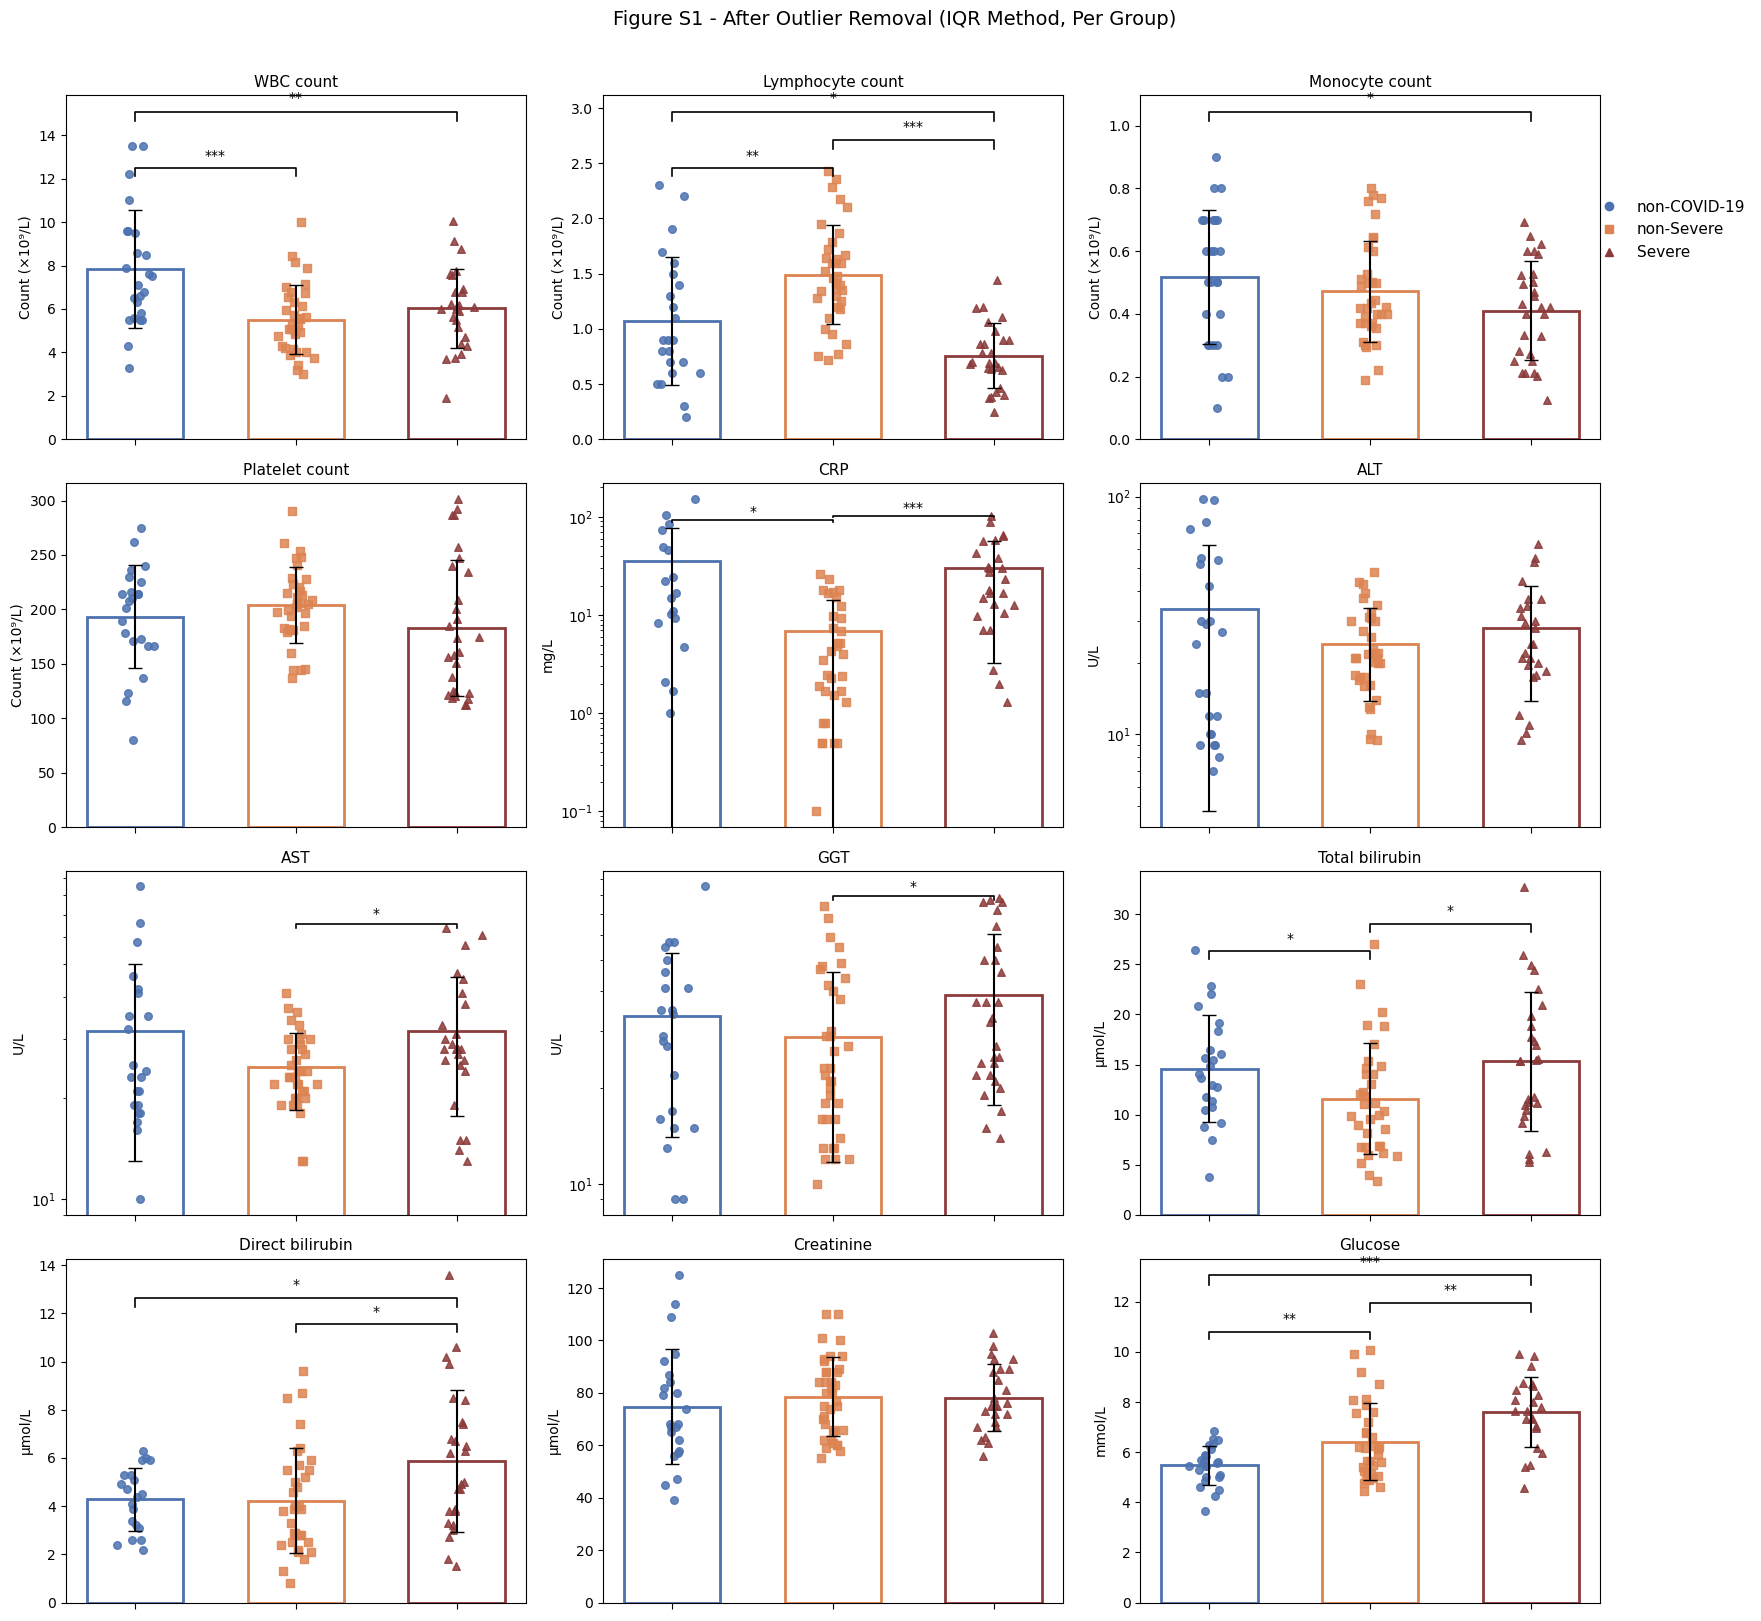

In [20]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for ax, (var, ylabel) in zip(axes, variables):
    plot_bar_with_points(ax, sup_fig_clean, var, ylabel)

for ax in axes[len(variables):]:
    ax.axis('off')

legend_elements = [
    Line2D([0], [0], color=colors[0], marker=markers[0],
           linestyle='None', label='non-COVID-19'),
    Line2D([0], [0], color=colors[1], marker=markers[1],
           linestyle='None', label='non-Severe'),
    Line2D([0], [0], color=colors[2], marker=markers[2],
           linestyle='None', label='Severe')
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(0.98, 0.90),
    frameon=False,
    fontsize=11
)

fig.suptitle("Figure S1 - After Outlier Removal (IQR Method, Per Group)", fontsize=14, y=1.01)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


### Discussion: How Results Changed After Outlier Removal

**Biomarkers Most Affected:**
- **Liver enzymes (ALT, AST):** These had extreme outliers (824 U/L, 743 U/L) likely from patients with severe hepatic injury. Removal clarifies typical group patterns.
- **Bilirubin (TBIL, DBIL):** Similar pattern - extreme values from hepatic dysfunction now excluded.
- **Glucose:** High outliers likely from diabetic patients or stress hyperglycemia - removal shows more typical metabolic patterns.

**Limitations:**
- Some removed "outliers" may represent true biological variability (e.g., severe hepatic injury in COVID-19 patients).



# Exercise 3
Create a heatmap of the biomarker data. Include group and gender as annotation variables.

In [21]:
biomarkers = ['WBC count, ×109/L', 'Lymphocyte count, ×109/L', 
              'Monocyte count, ×109/L', 'Platelet count, ×109/L', 
              'CRP i, mg/L', 'ALT j,  U/L', 'AST k, U/L', 
              'GGT l, U/L', 'TBIL m, μmol/L', 'DBIL n, μmol/L', 
              'Creatinine, μmol/L', 'Glucose, mmol/L']

heatmap_data = data[biomarkers + ['Group d', "Sex g"]]
heatmap_data = heatmap_data.apply(pd.to_numeric, errors='coerce')
heatmap_data = heatmap_data.dropna()
group_values = {0: "Healthy", 1: "non-COVID-19" ,2: "non-Severe", 3: "Severe", 4: "Total"}
sex_values = {0: "Female", 1: "Male"}
heatmap_data = heatmap_data.replace({"Group d": group_values, "Sex g": sex_values})
heatmap_data = heatmap_data.groupby(["Group d", "Sex g"]).agg(list)
heatmap_data = heatmap_data.map(lambda x: np.mean(x) if isinstance(x, list) else x)
heatmap_labels = [x[0] + " " +  x[1] for x in heatmap_data.index.to_flat_index().tolist()]
heatmap_data.index = heatmap_labels
heatmap_data

,"WBC count, ×109/L","Lymphocyte count, ×109/L","Monocyte count, ×109/L","Platelet count, ×109/L","CRP i, mg/L","ALT j, U/L","AST k, U/L","GGT l, U/L","TBIL m, μmol/L","DBIL n, μmol/L","Creatinine, μmol/L","Glucose, mmol/L"
Severe Female,8.019167,0.713456,0.389569,190.500000,48.020833,26.666667,32.250000,41.666667,11.991667,4.541667,81.333333,8.771667
Severe Male,6.060625,0.955644,0.424992,176.937500,35.754375,35.712500,40.250000,37.187500,19.100000,7.631250,101.562500,10.265625
non-COVID-19 Female,8.240000,1.100000,0.540000,214.600000,81.880000,19.800000,24.800000,24.200000,13.000000,3.980000,58.800000,5.592000
non-COVID-19 Male,9.246667,1.166667,0.533333,180.200000,50.546667,40.533333,55.333333,47.733333,24.006667,10.366667,86.733333,6.042667
non-Severe Female,6.279286,1.643806,0.448991,233.214286,11.410000,25.450000,24.142857,34.928571,9.121429,3.414286,71.357143,7.790000
non-Severe Male,5.643478,1.495412,0.542251,191.739130,14.287826,26.060870,25.130435,28.521739,15.869565,5.965217,83.000000,6.659130


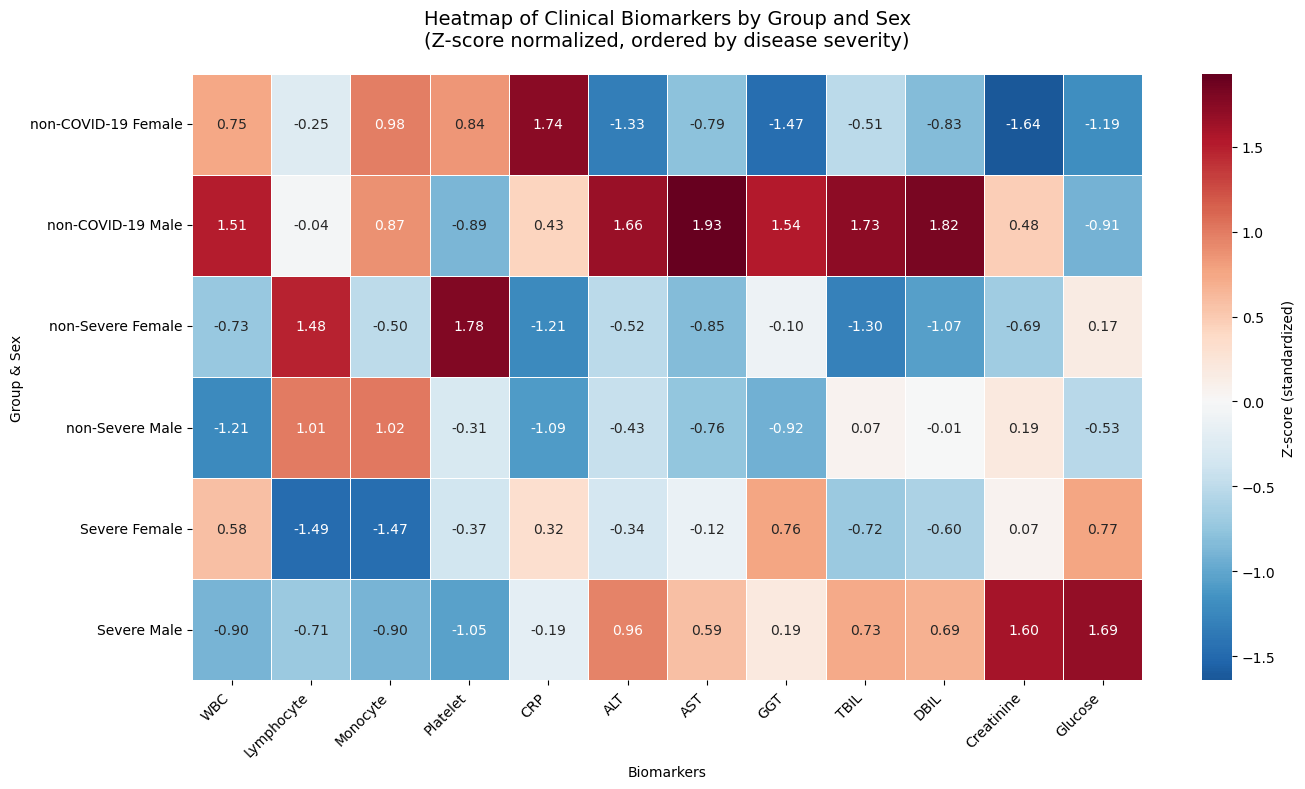

In [22]:
row_order = [
    'non-COVID-19 Female', 'non-COVID-19 Male',
    'non-Severe Female', 'non-Severe Male', 
    'Severe Female', 'Severe Male'
]

heatmap_ordered = heatmap_data.loc[row_order]

scaler = StandardScaler()
heatmap_scaled = pd.DataFrame(
    scaler.fit_transform(heatmap_ordered),
    index=heatmap_ordered.index,
    columns=heatmap_ordered.columns
)

col_labels = ['WBC', 'Lymphocyte', 'Monocyte', 'Platelet', 'CRP', 
              'ALT', 'AST', 'GGT', 'TBIL', 'DBIL', 'Creatinine', 'Glucose']

fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    heatmap_scaled,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    xticklabels=col_labels,
    yticklabels=row_order,
    cbar_kws={'label': 'Z-score (standardized)'},
    linewidths=0.5,
    ax=ax
)

ax.set_xlabel('Biomarkers')
ax.set_ylabel('Group & Sex')
ax.set_title('Heatmap of Clinical Biomarkers by Group and Sex\n(Z-score normalized, ordered by disease severity)', 
             fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Conclusion

The analysis of twelve clinical parameters across COVID-19 patient groups reveals distinct biomarker profiles that correlate with disease severity.   
**Severe COVID-19 patients** exhibited marked lymphopenia (lymphocyte count significantly lower than non-severe cases, $p<0.001$), consistent with immune dysregulation as a hallmark of severe disease.    
Inflammatory markers, particularly **CRP**, were substantially elevated in severe cases compared to non-severe COVID-19 patients, reflecting heightened systemic inflammation.    
**Glucose levels** were notably higher in severe patients (mean $~9-10$ mmol/L vs $~6-7$ mmol/L in non-severe), suggesting metabolic dysregulation or stress hyperglycemia.   
Liver function markers (**ALT, AST, bilirubin**) showed wider variability in severe cases, with some patients displaying hepatic involvement.    Interestingly, **non-COVID-19 patients** (other respiratory infections) showed elevated CRP and liver enzymes comparable to or exceeding COVID-19 groups, indicating that inflammation and organ stress are not unique to COVID-19 but common to severe respiratory illness.    
Sex differences were observed across groups, with males generally showing higher creatinine (reflecting baseline physiological differences) and somewhat higher liver enzyme levels.     
The heatmap visualization clearly demonstrates the progression from non-COVID controls through non-severe to severe COVID-19, with lymphocyte depletion and glucose elevation emerging as the most distinguishing features of severe disease. These findings align with the original publication and support the use of lymphocyte count and inflammatory markers as potential prognostic indicators for COVID-19 severity.